# Runtime

$\newcommand{\ket}[1]{\left|#1\right\rangle} \newcommand{\bra}[1]{\left\langle #1\right|} \newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle} \newcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}
$This notebook expains how to calculate the queries and runtime of each device. 



In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from monaqa2.data.plot_main import plot_annealing_classical_queries_and_quantum_queries_vs_n
from monaqa2.data.plot_main import plot_annealing_classical_queries_and_quantum_runtime_vs_n

## Promise on the annealing schedule

We consider an annealing schedule $\beta_0=0<\beta_1<\cdots<\beta_F$ where $\beta_F$ reaches at most the value $100$. 

For each consecutive pair, we require
$$\left(\sum_x \sqrt{\pi_{\beta_k}(x)\pi_{\beta_{k+1}}(x)}\right)^2 = |\braket{\pi_{\beta_k}}{\pi_{\beta_{k+1}}}|^2 \ge 1/e$$

## Per-platform queries

For the classical walks, the number of queries is the total number of Metropolis proposals executed along the annealing schedule. If $q_t^{\rm loc}(n,\varepsilon)$, $q_t^{\rm unif}(n,\varepsilon)$, and $q_t^{\rm qemc}(n,\varepsilon)$ are the fitted query counts at annealing step $t$, then

* Local proposal: $Q_{\rm loc}(n,\varepsilon)=\sum_t q_t^{\rm loc}(n,\varepsilon)$.
* Uniform proposal: $Q_{\rm unif}(n,\varepsilon)=\sum_t q_t^{\rm unif}(n,\varepsilon)$.
* QEMC proposal: $Q_{\rm qemc}(n,\varepsilon)=\sum_t q_t^{\rm qemc}(n,\varepsilon)$.

For the quantum-walk methods, the query count is the total QSP/QSVT filter degree over the annealing schedule. Given the fitted spectral gap $\delta_t$ at step $t$, the corresponding phase gap is $\Delta_{\theta,t}=\arccos(1-\delta_t)$ and the filter degree is $f_t=2\lceil\ln(1/\varepsilon)/\Delta_{\theta,t}\rceil$. Thus

* Quantum walk with local move: $F_{\rm loc}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm loc})\rceil$.
* Quantum walk with uniform move: $F_{\rm unif}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm unif})\rceil$.
* Quantum walk with QEMC move: $F_{\rm qemc}(n,\varepsilon)=\sum_t 2\lceil\ln(1/\varepsilon)/\arccos(1-\delta_t^{\rm qemc})\rceil$.

Here $Q$ counts classical Metropolis proposals, while $F$ counts calls to the quantum walk or its inverse inside the QSP/QSVT spectral filter.

## Per-platform runtime

For the classical local and uniform walks, the runtime is the number of executed Metropolis steps times a fitted per-step cost. For an annealing schedule with query counts $q_1,\ldots,q_T$, the total number of steps is $Q=\sum_{t=1}^T q_t$.

* Local proposal:
  * CPU: $T_{\rm CPU}^{\rm loc}(n)=Q\left(5.959\cdot10^{-9}+1.429\cdot10^{-10}n\right)$.
  * GPU: $T_{\rm GPU}^{\rm loc}(n)=Q\left(7.837\cdot10^{-7}+1.459\cdot10^{-9}n\right)$.
  * FPGA: $T_{\rm FPGA}^{\rm loc}(n)=Q\left(2.679\cdot10^{-7}+1.800\cdot10^{-9}\log_2 n\right)$.

* Uniform proposal:
  * CPU: $T_{\rm CPU}^{\rm unif}(n)=Q\left(1.173\cdot10^{-8}n+6.964\cdot10^{-11}n^2\right)$.
  * GPU: $T_{\rm GPU}^{\rm unif}(n)=Q\left(2.215\cdot10^{-10}n^2\right)$.
  * FPGA: $T_{\rm FPGA}^{\rm unif}(n)=Q\left(2.541\cdot10^{-7}+4.200\cdot10^{-9}\log_2 n\right)$.

For the classical walk with QEMC move, each Metropolis proposal calls a small quantum circuit. The surface-code distance is chosen from the spacetime volume of one Hamiltonian-simulation query, and the resulting physical time is multiplied by the number of queries.

* QEMC proposal:
  * Logical time per query: $L^{\rm qemc}(n)=1+r(n+2)$, with $r=50$ in the default setting.
  * Logical space per query: $S^{\rm qemc}(n)=n$.
  * Surface-code distance: $d=d_{\rm qemc}(n)$ is the smallest odd integer such that $L^{\rm qemc}(n)S^{\rm qemc}(n)d\,0.1(100p_{\rm phys})^{(d+1)/2}\le 1/3$.
  * Physical time: $T^{\rm qemc}(n)=Q\,L^{\rm qemc}(n)d_{\rm qemc}(n)(4t_{\rm phys}+t_{\rm meas})$.

The quantum walk approach can be implemented either by a sequence of QPE calls or by a sequence of spectral filters via QSP/QSVT. Since we do not need to keep an eigenvalue register, we use the QSP-filter implementation. At annealing step $t$, the filter degree is $f_t=2\lceil\ln(1/\varepsilon)/\Delta_{\theta,t}\rceil$, where $\Delta_{\theta,t}=\arccos(1-\delta_t)$ is the phase gap. We set $F=\sum_t f_t$ and use implementation error $\frac{\varepsilon}{F}$ inside each walk circuit.

* Quantum walk with local move:
  * Logical time for a single local walk: $L_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single local walk: $S_Q^{\rm local}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the local move: $d_Q^{\rm local}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm local}=\left(\sum_t f_tL_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm local}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with local move: $T_Q^{\rm local}(n)=d_Q^{\rm local}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm local}(n,\beta_t,\frac{\varepsilon}{F})$.

* Quantum walk with uniform move:
  * Logical time for a single uniform walk: $L_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single uniform walk: $S_Q^{\rm uniform}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the uniform move: $d_Q^{\rm uniform}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm uniform}=\left(\sum_t f_tL_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm uniform}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with uniform move: $T_Q^{\rm uniform}(n)=d_Q^{\rm uniform}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm uniform}(n,\beta_t,\frac{\varepsilon}{F})$.

* Quantum walk with QEMC move:
  * Logical time for a single QEMC walk: $L_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})$.
  * Logical space for a single QEMC walk: $S_Q^{\rm qemc}(n,\frac{\varepsilon}{F})$.
  * Surface-code distance for the QEMC move: $d_Q^{\rm qemc}(n)$ is chosen from the full-walk spacetime volume $V_Q^{\rm qemc}=\left(\sum_t f_tL_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})\right)S_Q^{\rm qemc}(n,\frac{\varepsilon}{F})$.
  * Quantum walk with QEMC move: $T_Q^{\rm qemc}(n)=d_Q^{\rm qemc}(n)(4t_{\rm phys}+t_{\rm meas})\sum_t f_tL_Q^{\rm qemc}(n,\beta_t,\frac{\varepsilon}{F})$.


## Annealing schedule

### Worst-case, loose bounds on the annealing schedule

[Wocjan and Abeyesinghe, Section V](https://arxiv.org/pdf/0804.4259) gives a worst-case annealing-step rule for Boltzmann-Gibbs states. For a classical Hamiltonian $H$ with energies $E(x)\ge0$, the coherent Gibbs states satisfy 
$$|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}|^2\ge \exp(-\|H\|\Delta\beta)$$ 
for all $\beta$ and all $\Delta\beta$. Here $\| H \|$ is the operator norm. 

Therefore, choosing $\Delta\beta=1/\|H\|$ guarantees $|\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}|^2 \ge 1/e$. In the worst case, reaching inverse temperature $\beta$ requires $r=\beta\|H\|$ annealing steps, with $\beta_i=i/\|H\|$ for $i=0,\ldots,r$.

For the SK model we have that $\|H\| \approx 2n$ (shown numerically in notebook 0_data.ipynb).

In [2]:
def worst_case_annealing(n: int, beta: float) -> list[float]:
    step = 1.0 / (2.0 * n)
    num_steps = int(np.ceil(beta / step))
    return list(np.linspace(0.0, beta, num_steps + 1)[1:])

### Tight bounds on the annealing schedule

We developed an improved approach, presented in the notebook `4.1_heuristic_scheduling.ipynb`, which gives

$$
\Delta\beta(n, \beta) = \frac{2}{\sqrt{n v(\beta)}} = \frac{1}{\sqrt{n}}
\begin{cases}
\exp\left(-0.111\,\beta + 0.615\,\beta^2\right), & \beta<1,\\[3mm]
0.533\,(\beta+0.286)^{7/4}, & \beta\geq1.
\end{cases}
$$

In [3]:
def delta_beta(n, beta):
    beta = np.asarray(beta, dtype=float)
    return np.where(beta < 1.0, np.exp(-0.111 * beta + 0.615 * beta**2), 0.533 * (beta + 0.286)**1.75) / np.sqrt(n)

def tight_schedule_annealing(n: int, beta: float) -> list[float]:
    schedule = [0.0]
    while schedule[-1] < beta:
        next_beta = schedule[-1] + float(delta_beta(n, schedule[-1]))
        schedule.append(min(next_beta, beta))
    return schedule

In [47]:
from monaqa2.data.spectral_gap import get_spectral_gap_stats, get_spectral_gap_fit_by_n
from monaqa2.data.runtime import get_annealing_time_quantum_walk_uniform

beta = 4.0
epsilon = 1e-2

n = 55
schedule_55 = tight_schedule_annealing(n, beta)
spectral_gaps_55 = []

for beta_t in schedule_55:
    A_g, b_g = get_spectral_gap_fit_by_n(proposal="uniform", a=np.inf, fixed_beta=beta_t)
    spectral_gaps_55.append(A_g * np.exp(-b_g * n))

res_n55 = get_annealing_time_quantum_walk_uniform(n, epsilon, schedule_55, spectral_gaps_55, physical_operation_time=1e-8, physical_measurement_time=1e-7, physical_error_rate=1e-4, num_trotter_steps=50)
print(f"{n=} {res_n55=:.6e}")

n=55 res_n55=6.452818e+08


In [49]:
n = 60
schedule_60 = tight_schedule_annealing(n, beta)
spectral_gaps_60 = []

for beta_t in schedule_60:
    A_g, b_g = get_spectral_gap_fit_by_n(proposal="uniform", a=np.inf, fixed_beta=beta_t)
    spectral_gaps_60.append(A_g * np.exp(-b_g * n))

res_n60 = get_annealing_time_quantum_walk_uniform(n, epsilon, schedule_60, spectral_gaps_60, physical_operation_time=1e-8, physical_measurement_time=1e-7, physical_error_rate=1e-4, num_trotter_steps=50)
print(f"{n=} {res_n60=:.6e}")

n=60 res_n60=3.665173e+17


In [23]:
np.array(schedule_55), len(schedule_55)

(array([0.        , 0.13483997, 0.26917048, 0.40600458, 0.54865522,
        0.70133104, 0.870135  , 1.06516272, 1.18686095, 1.32838457,
        1.49455667, 1.69180735, 1.92887257, 2.21787811, 2.57607262,
        3.02869602, 3.61392032, 4.        ]),
 18)

In [24]:
np.array(schedule_60), len(schedule_60)

(array([0.        , 0.12909944, 0.25767323, 0.38836145, 0.52403234,
        0.66824666, 0.82600085, 1.00519996, 1.11281927, 1.23662319,
        1.3802344 , 1.54838165, 1.74733834, 1.98558042, 2.27479873,
        2.63150325, 3.07965123, 3.65512101, 4.        ]),
 19)

In [28]:
spectral_gaps_55 = np.array(spectral_gaps_55)
spectral_gaps_55, spectral_gaps_55.min()

(array([9.93964148e-01, 1.25876640e-03, 4.42854512e-06, 3.83561569e-08,
        8.11941198e-10, 3.10751282e-11, 2.24704911e-12, 3.26855486e-13,
        1.70504594e-13, 7.99974063e-14, 3.28983850e-14, 1.14577538e-14,
        3.22524813e-15, 1.56317118e-15, 8.88030894e-16, 4.45614051e-16,
        2.94441003e-16, 2.24014470e-16]),
 np.float64(2.2401447003619683e-16))

In [29]:
spectral_gaps_60 = np.array(spectral_gaps_60)
spectral_gaps_60, spectral_gaps_60.min()

(array([9.93417608e-01, 9.06089584e-04, 2.34353684e-06, 1.48539260e-08,
        2.27714530e-10, 6.96390135e-12, 3.77252110e-13, 3.34038367e-14,
        1.78386944e-14, 8.66880427e-15, 3.75330696e-15, 1.40850097e-15,
        4.41679795e-16, 1.10156159e-16, 6.31625294e-17, 3.42213427e-17,
        1.70884567e-17, 1.09719775e-17, 8.41334818e-18]),
 np.float64(8.41334818252291e-18))

In [56]:
from monaqa2.data.runtime import spectral_gap_to_filter_degree, quantum_walk_uniform_circuit, rotated_surface_code_time

def y_get_annealing_time_quantum_walk_uniform(n: int, eps: float, betas: list[float], spectral_gaps: list[float], physical_operation_time: float, physical_measurement_time: float, physical_error_rate: float, num_trotter_steps: int = 50) -> float:
    assert len(betas) == len(spectral_gaps)
    degree_filters = [spectral_gap_to_filter_degree(spectral_gap, np.log2(1/eps)) 
                      for spectral_gap in spectral_gaps]
    F = sum(degree_filters)

    print(f"{n=} {sum(degree_filters)=:.5e}")
    
    logical_time = 0
    logical_space = 0
    for beta, degree in zip(betas, degree_filters):
        walk_time, walk_space = quantum_walk_uniform_circuit(n, eps / F, beta)
        logical_time_step = degree * walk_time
        logical_time += logical_time_step
        print(f"\t{beta=:3.3f} {degree=:.5e} {logical_time_step=:.5e}")
        logical_space = max(logical_space, walk_space)

    print(f"\tFinal logical time: {logical_time:.5e}")
    physical_time = rotated_surface_code_time(logical_time, logical_space, physical_operation_time, physical_measurement_time, physical_error_rate)
    print(f"\tFinal physical time: {physical_time:.5e}")
    return physical_time

In [57]:
n = 55
res_n55 = y_get_annealing_time_quantum_walk_uniform(n, epsilon, schedule_55, spectral_gaps_55, physical_operation_time=1e-8, physical_measurement_time=1e-7, physical_error_rate=1e-4, num_trotter_steps=50)
print(f"{n=} {res_n55=:.6e}")

n=55 sum(degree_filters)=2.53085e+09
	beta=0.000 degree=8.49185e+00 logical_time_step=7.50633e+05
	beta=0.135 degree=2.64799e+02 logical_time_step=2.34068e+07
	beta=0.269 degree=4.46483e+03 logical_time_step=3.94666e+08
	beta=0.406 degree=4.79753e+04 logical_time_step=4.24075e+09
	beta=0.549 degree=3.29741e+05 logical_time_step=2.91473e+10
	beta=0.701 degree=1.68550e+06 logical_time_step=1.48989e+11
	beta=0.870 degree=6.26794e+06 logical_time_step=5.54051e+11
	beta=1.065 degree=1.64347e+07 logical_time_step=1.45277e+12
	beta=1.187 degree=2.27528e+07 logical_time_step=2.01136e+12
	beta=1.328 degree=3.32095e+07 logical_time_step=2.93587e+12
	beta=1.495 degree=5.18304e+07 logical_time_step=4.58223e+12
	beta=1.692 degree=8.78641e+07 logical_time_step=7.76824e+12
	beta=1.929 degree=1.65589e+08 logical_time_step=1.46407e+13
	beta=2.218 degree=2.38323e+08 logical_time_step=2.10725e+13
	beta=2.576 degree=3.15272e+08 logical_time_step=2.78775e+13
	beta=3.029 degree=4.45862e+08 logical_time_step

In [58]:
n=60
res_n60 = y_get_annealing_time_quantum_walk_uniform(n, epsilon, schedule_60, spectral_gaps_60, physical_operation_time=1e-8, physical_measurement_time=1e-7, physical_error_rate=1e-4, num_trotter_steps=50)
print(f"{n=} {res_n60=:.6e}")

n=60 sum(degree_filters)=5.31508e+17
	beta=0.000 degree=8.49482e+00 logical_time_step=1.41156e+06
	beta=0.129 degree=3.12117e+02 logical_time_step=5.18637e+07
	beta=0.258 degree=6.13761e+03 logical_time_step=1.01987e+09
	beta=0.388 degree=7.70929e+04 logical_time_step=1.28103e+10
	beta=0.524 degree=6.22644e+05 logical_time_step=1.03463e+11
	beta=0.668 degree=3.56049e+06 logical_time_step=5.91638e+11
	beta=0.826 degree=1.52974e+07 logical_time_step=2.54194e+12
	beta=1.005 degree=5.13981e+07 logical_time_step=8.54071e+12
	beta=1.113 degree=7.02776e+07 logical_time_step=1.16782e+13
	beta=1.237 degree=1.00968e+08 logical_time_step=1.67785e+13
	beta=1.380 degree=1.52929e+08 logical_time_step=2.54140e+13
	beta=1.548 degree=2.47320e+08 logical_time_step=4.11009e+13
	beta=1.747 degree=4.45862e+08 logical_time_step=7.40977e+13
	beta=1.986 degree=8.91723e+08 logical_time_step=1.48199e+14
	beta=2.275 degree=8.91723e+08 logical_time_step=1.48203e+14
	beta=2.632 degree=1.32877e+17 logical_time_step

In [62]:
spectral_gaps_55 = np.array(spectral_gaps_55)
degree_55 = np.array([spectral_gap_to_filter_degree(spectral_gap, np.log2(1/epsilon)) 
                      for spectral_gap in spectral_gaps_55])
spectral_gaps_60 = np.array(spectral_gaps_60)
degree_60 = np.array([spectral_gap_to_filter_degree(spectral_gap, np.log2(1/epsilon)) 
                      for spectral_gap in spectral_gaps_60])

In [63]:
spectral_gaps_55, spectral_gaps_60

(array([9.93964148e-01, 1.25876640e-03, 4.42854512e-06, 3.83561569e-08,
        8.11941198e-10, 3.10751282e-11, 2.24704911e-12, 3.26855486e-13,
        1.70504594e-13, 7.99974063e-14, 3.28983850e-14, 1.14577538e-14,
        3.22524813e-15, 1.56317118e-15, 8.88030894e-16, 4.45614051e-16,
        2.94441003e-16, 2.24014470e-16]),
 array([9.93417608e-01, 9.06089584e-04, 2.34353684e-06, 1.48539260e-08,
        2.27714530e-10, 6.96390135e-12, 3.77252110e-13, 3.34038367e-14,
        1.78386944e-14, 8.66880427e-15, 3.75330696e-15, 1.40850097e-15,
        4.41679795e-16, 1.10156159e-16, 6.31625294e-17, 3.42213427e-17,
        1.70884567e-17, 1.09719775e-17, 8.41334818e-18]))

In [64]:
degree_55, degree_60

(array([8.49185093e+00, 2.64799452e+02, 4.46482585e+03, 4.79752975e+04,
        3.29740989e+05, 1.68549961e+06, 6.26794031e+06, 1.64346781e+07,
        2.27527816e+07, 3.32095105e+07, 5.18303630e+07, 8.78641059e+07,
        1.65588857e+08, 2.38323072e+08, 3.15271790e+08, 4.45861641e+08,
        5.14836677e+08, 6.30543580e+08]),
 array([8.49481806e+00, 3.12116591e+02, 6.13760936e+03, 7.70929373e+04,
        6.22644083e+05, 3.56049001e+06, 1.52974280e+07, 5.13980756e+07,
        7.02776399e+07, 1.00967779e+08, 1.52929281e+08, 2.47319540e+08,
        4.45861641e+08, 8.91723283e+08, 8.91723283e+08, 1.32877124e+17,
        1.32877124e+17, 1.32877124e+17, 1.32877124e+17]))

In [69]:
print(f"{spectral_gap_to_filter_degree(1e-16, np.log2(1/1e-2)):.6e}")

8.917233e+08


In [70]:
print(f"{spectral_gap_to_filter_degree(1e-17, np.log2(1/1e-2)):.6e}")

1.328771e+17


## Loose-annealing schedule runtime plots 

Classical device here is FPGA. 


KeyboardInterrupt


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x7ebdde18bab0> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



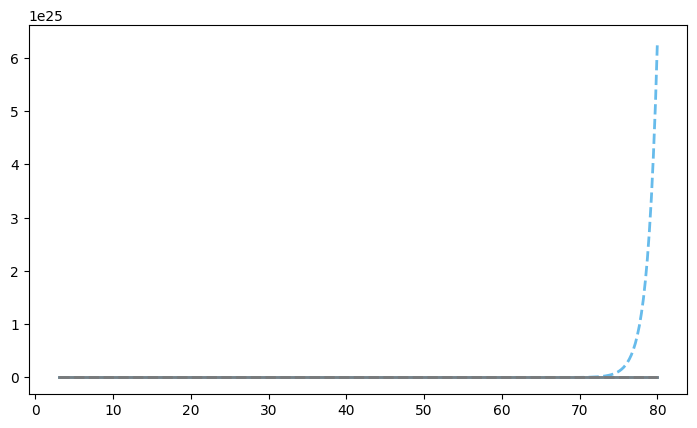

In [ ]:
fig, ax = plot_annealing_classical_queries_and_quantum_runtime_vs_n(
    beta=4.0, 
    epsilon=1e-2, 
    annealing_schedule_generator=worst_case_annealing,
    n_plot_min=3, 
    n_plot_max=80,
    physical_operation_time = 10e-9, 
    physical_measurement_time = 100e-9, 
    physical_error_rate = 1e-4
)

In [ ]:
fig, ax = plot_annealing_classical_queries_and_quantum_runtime_vs_n(
    beta=4.0, 
    epsilon=1e-2, 
    annealing_schedule_generator=worst_case_annealing,
    n_plot_min=3, 
    n_plot_max=80,
    physical_operation_time = 60e-9, 
    physical_measurement_time = 400e-9, 
    physical_error_rate = 5e-3
)

## Heuristic choice of the annealing step

